<a href="https://colab.research.google.com/github/sumitkharayat/Linear-Regression/blob/main/Binary%20classification%20model%20for%20abnormal%20physiological%20signals%20of%20human%20body.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement a classification model to distinguish between normal and abnormal
physiological signals using extracted signal features


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

In [ ]:
!pip install xgboost

loading datasets

 MIT-BIH (multiclass: 0=Normal, 1=Supra, 2=Ventricular, 3=Fusion, 4=Unknown)

In [ ]:
mitbih_train = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 9-10/mitbih_train.csv', header=None)
mitbih_test  = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 9-10/mitbih_test.csv',  header=None)
ptbdb_normal   = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 9-10/ptbdb_normal.csv',   header=None)
ptbdb_abnormal = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 9-10/ptbdb_abnormal.csv', header=None)

In [ ]:
Normal = 0
Abnormal = 1

In [ ]:
ptbdb_normal['label'] = 0
ptbdb_abnormal['label'] = 1

combining the data sets

In [ ]:
data = pd.concat([ptbdb_normal, ptbdb_abnormal], axis=0)

In [ ]:
data = data.sample(frac=1, random_state=42)

In [ ]:
X = data.drop("label", axis=1)
y = data["label"]

Train test split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Decision Tree"     : DecisionTreeClassifier(random_state=42),
    "Random Forest"     : RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN"               : KNeighborsClassifier(n_neighbors=5),
    "XGBoost"           : XGBClassifier(use_label_encoder=False,
                                         eval_metric='mlogloss',
                                         random_state=42)
}

In [ ]:
print("MIT-BIH Train shape:", mitbih_train.shape)
print("MIT-BIH Test shape :", mitbih_test.shape)
print("PTB Normal shape   :", ptbdb_normal.shape)
print("PTB Abnormal shape :", ptbdb_abnormal.shape)


MIT-BIH Train shape: (87554, 188)
MIT-BIH Test shape : (21892, 188)
PTB Normal shape   : (4046, 189)
PTB Abnormal shape : (10506, 189)


Train and evaluate


In [ ]:
results = {}

for name, model in models.items():

    if name in ["Logistic Regression","KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\nModel:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


Model: Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00      2106

    accuracy                           1.00      2911
   macro avg       1.00      1.00      1.00      2911
weighted avg       1.00      1.00      1.00      2911


Model: Random Forest
Accuracy: 0.9996564754379939
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00      2106

    accuracy                           1.00      2911
   macro avg       1.00      1.00      1.00      2911
weighted avg       1.00      1.00      1.00      2911


Model: Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00      2106

    accuracy                           1.00      2911

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:14:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBoost
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       805
           1       1.00      1.00      1.00      2106

    accuracy                           1.00      2911
   macro avg       1.00      1.00      1.00      2911
weighted avg       1.00      1.00      1.00      2911



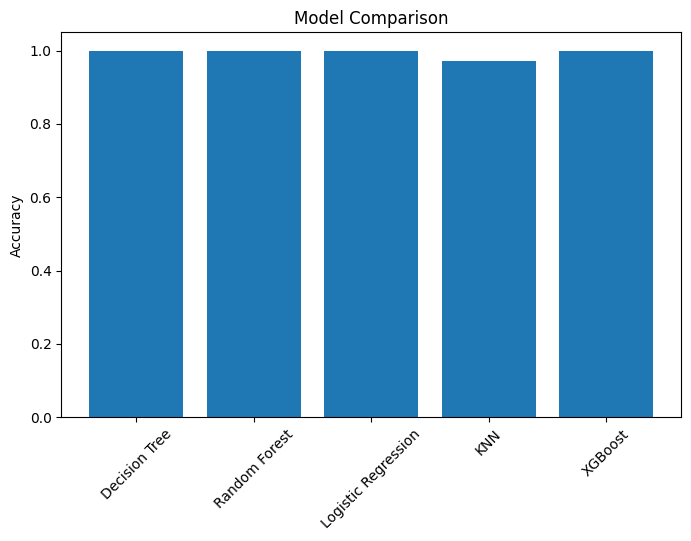

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [ ]:
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]


Best Model: Decision Tree


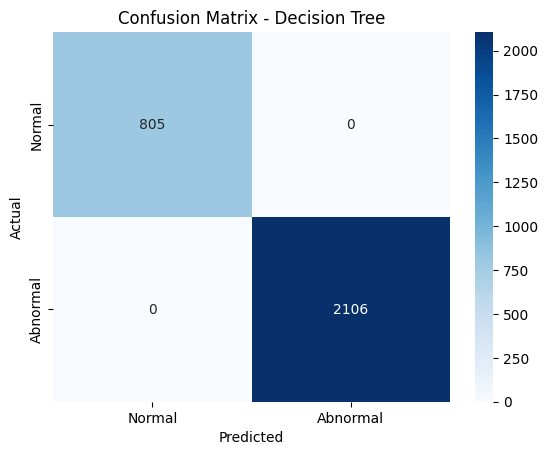

In [ ]:
if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Labels for binary classification
plt.xticks([0.5,1.5], ["Normal", "Abnormal"])
plt.yticks([0.5,1.5], ["Normal", "Abnormal"])

plt.show()